In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

import os


### summary statistics of cases_data.csv

In [92]:
df_cases_data = pd.read_csv('../data/processed/cases_data.csv')

# print(df_cases_data[['optype']].value_counts())

# print(df_cases_data[['sex']].value_counts())

# print(df_cases_data[['asa']].value_counts())

# print(df_cases_data[['propofol']].value_counts())

# print(df_cases_data[['volatile']].value_counts())

print(df_cases_data[['remifentanil']].value_counts())

# df_cases_data[['optype','sex','asa','propofol','volatile','remifentanil']].head()

remifentanil
True            271
False           135
Name: count, dtype: int64


# Overview of patient data

In [ ]:
# try to find patients without NaNs
import glob

data_dir = '../data/processed/eeg'

# Get a list of all .pt files in the directory
all_files = glob.glob(os.path.join(data_dir, '*.pt'))

print(f"Found {len(all_files)} processed cases.")

# Example of looping through the first 5 files
for file in all_files:
    data = torch.load(file, weights_only=False)
    # print(f"Case {data['caseid']} has {data['features'].shape[0]} seconds of data.")

# (Assuming data_dir is defined here)

all_files = glob.glob(os.path.join(data_dir, '*.pt'))
print(f"Found {len(all_files)} processed cases.")

# Lists to keep track of your cases
clean_caseids = []
nan_caseids = []

for file in all_files:
    # Load the data
    data = torch.load(file, weights_only=False)
    features = data['features']
    caseid = data['caseid']
    
    # torch.isnan() creates a boolean mask of NaNs.
    # .any() returns True if there is even a single True (NaN) in the mask.
    if not torch.isnan(features).any():
        clean_caseids.append(caseid)
    else:
        nan_caseids.append(caseid)

print(f"\n--- Results ---")
print(f"Total cases evaluated: {len(all_files)}")
print(f"Cases with NO NaNs: {len(clean_caseids)}")
print(f"Cases WITH NaNs: {len(nan_caseids)}")

# You can now view or use your clean case IDs
print(f"Clean Case IDs: {clean_caseids}")

Found 406 processed cases.
Found 406 processed cases.

--- Results ---
Total cases evaluated: 406
Cases with NO NaNs: 11
Cases WITH NaNs: 395
Clean Case IDs: [1015, 1459, 1596, 1910, 2274, 331, 4500, 4705, 4763, 5978, 747]


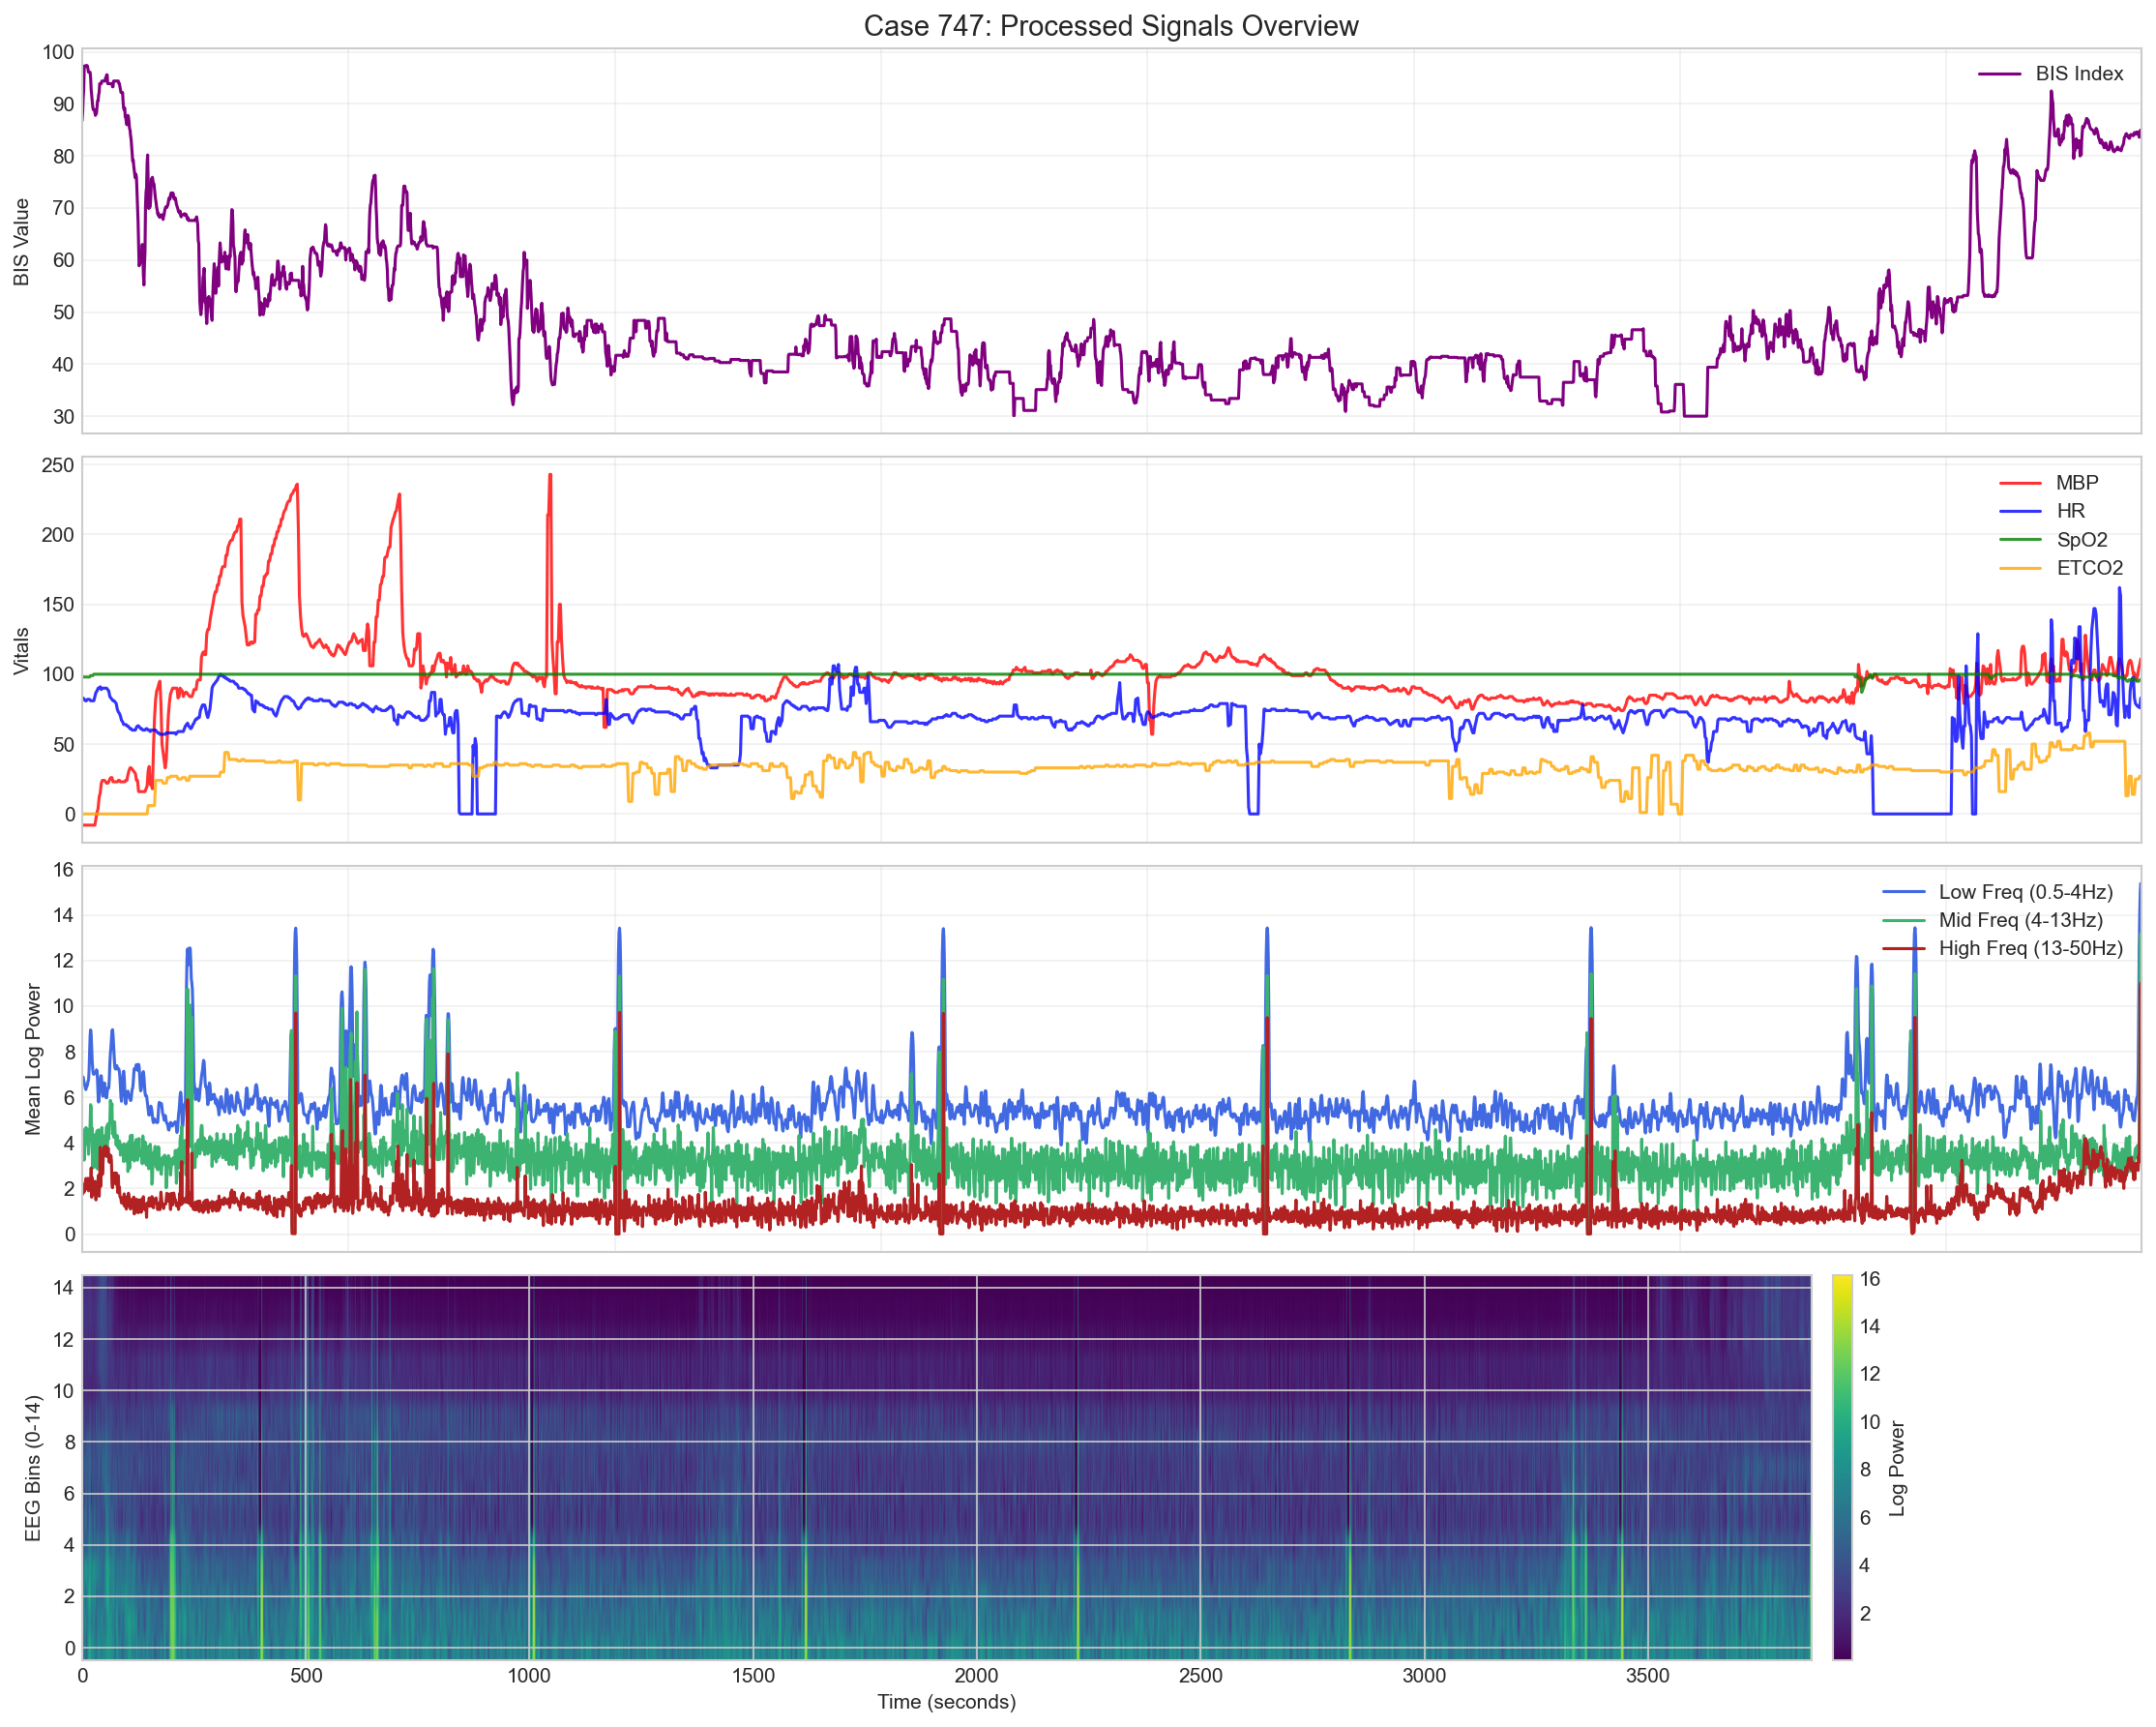

In [ ]:
# Convert PyTorch tensors to NumPy arrays for plotting
features_np = features.numpy()
bis_np = bis.numpy()

# The time axis is simply the number of rows (1 row = 1 second)
time_axis = np.arange(features_np.shape[0])

# Create a figure with 4 stacked subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# --- 1. Plot the Target: BIS Index ---
axes[0].plot(time_axis, bis_np, color='purple', label='BIS Index')
axes[0].set_ylabel('BIS Value')
axes[0].set_title(f'Case {caseid}: Processed Signals Overview')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# --- 2. Plot the Vitals (Features 15 to 18) ---
vitals_labels = ['MBP', 'HR', 'SpO2', 'ETCO2']
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    axes[1].plot(time_axis, features_np[:, 15 + i], label=vitals_labels[i], color=colors[i], alpha=0.8)
axes[1].set_ylabel('Vitals')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# --- 3. Plot Aggregated EEG Power Bands ---
# Averaging the 5 bins for each band to show general trends
axes[2].plot(time_axis, np.mean(features_np[:, 0:5], axis=1), label='Low Freq (0.5-4Hz)', color='royalblue')
axes[2].plot(time_axis, np.mean(features_np[:, 5:10], axis=1), label='Mid Freq (4-13Hz)', color='mediumseagreen')
axes[2].plot(time_axis, np.mean(features_np[:, 10:15], axis=1), label='High Freq (13-50Hz)', color='firebrick')
axes[2].set_ylabel('Mean Log Power')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

# --- 4. Plot EEG Features as a "Spectrogram" Heatmap ---
# We transpose (.T) so that Time is on the X-axis and Frequency bins are on the Y-axis
im = axes[3].imshow(features_np[:, 0:15].T, aspect='auto', cmap='viridis', origin='lower')
axes[3].set_ylabel('EEG Bins (0-14)')
axes[3].set_xlabel('Time (seconds)')
fig.colorbar(im, ax=axes[3], label='Log Power', pad=0.01)

plt.tight_layout()
plt.show()

# preprocessing_3.py

In [55]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import vitaldb
from scipy import ndimage
from scipy.signal import butter, sosfiltfilt

# --- Styling for Report-Quality Plots ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlesize'] = 14

# --- Constants ---
SAMPLING_RATE = 128
TRACKS = ['BIS/EEG1_WAV', 'BIS/BIS', 'Solar8000/ART_MBP', 'Solar8000/NIBP_MBP', 'Solar8000/HR', 'Solar8000/PLETH_SPO2', 'Solar8000/ETCO2']

EDGES = {
    'low': np.logspace(np.log10(0.5), np.log10(4), num=6),
    'mid': np.logspace(np.log10(4), np.log10(13), num=6),
    'high': np.logspace(np.log10(13), np.log10(50), num=6)
}

Loaded Case ID: 747
Features tensor shape: (3867, 19)
BIS tensor shape: (3867,)


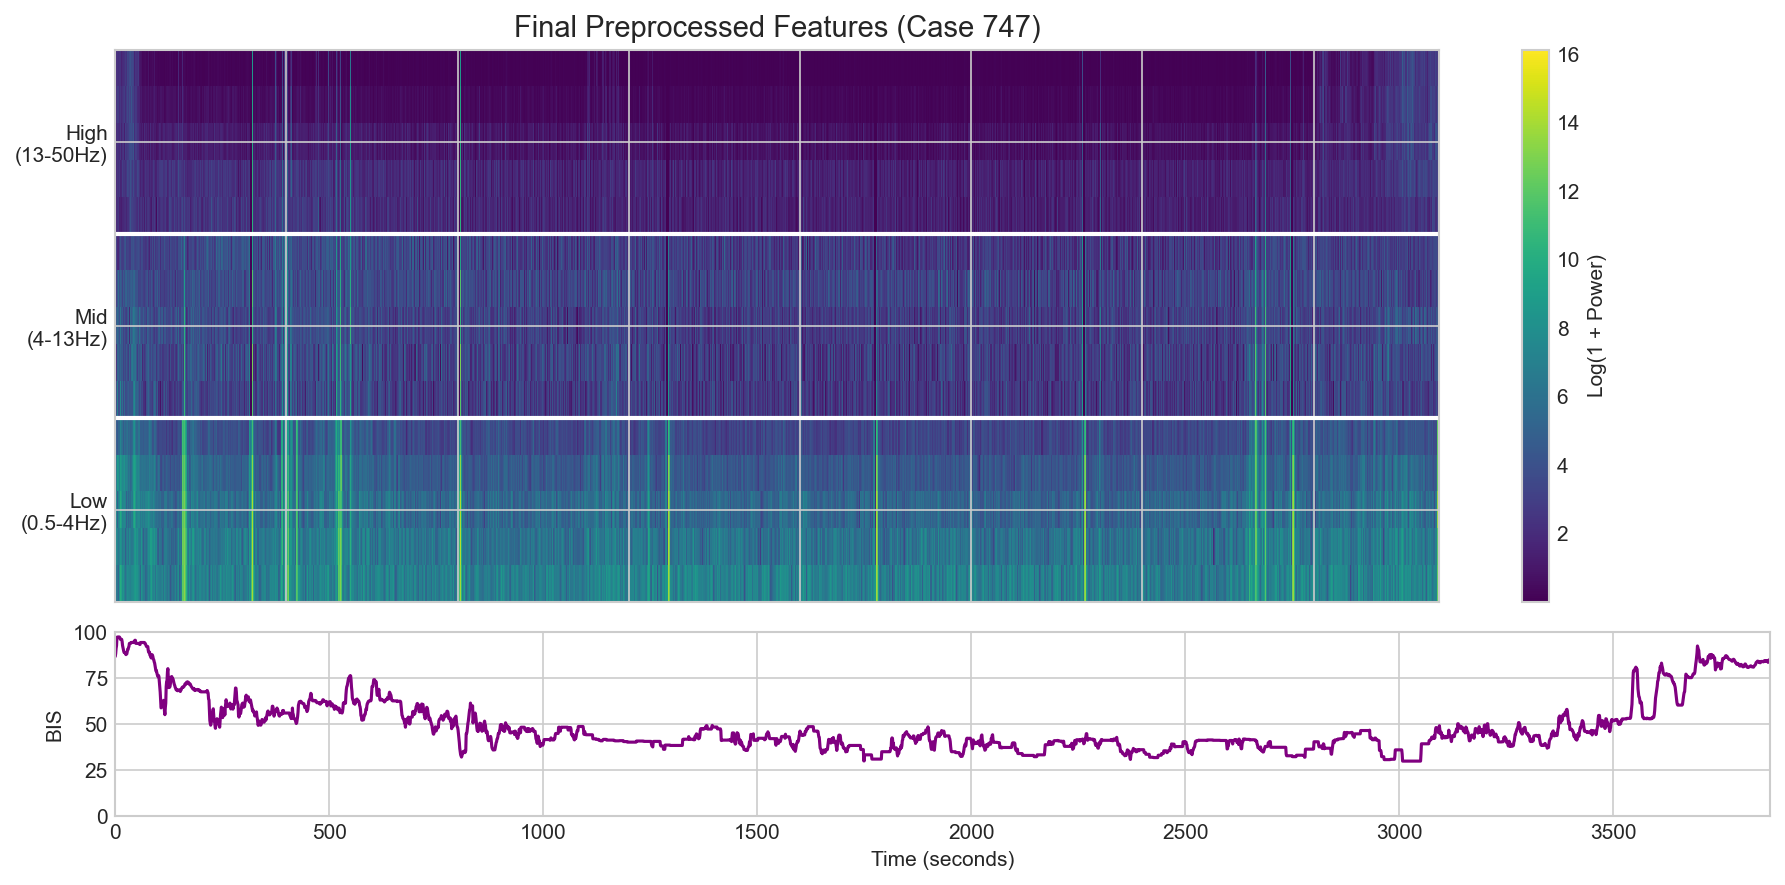

In [56]:
data_dir = '../data/processed/eeg'
file_path = os.path.join(data_dir, 'case_747.pt')

# Load the data using PyTorch
loaded_data = torch.load(file_path, weights_only=False)

features = loaded_data['features'].numpy() # Convert to numpy for plotting
bis = loaded_data['bis'].numpy()
caseid = loaded_data['caseid']

print(f"Loaded Case ID: {caseid}")
print(f"Features tensor shape: {features.shape}")
print(f"BIS tensor shape: {bis.shape}")

# --- Plot the Final Feature Matrix (Spectrogram) ---
# We extract just the first 15 columns (the EEG features, excluding vitals)
eeg_features = features[:, 0:15]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 1. Spectrogram
im = ax1.imshow(eeg_features.T, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
ax1.set_yticks([2, 7, 12])
ax1.set_yticklabels(['Low\n(0.5-4Hz)', 'Mid\n(4-13Hz)', 'High\n(13-50Hz)'])
ax1.axhline(4.5, color='white', linewidth=2)
ax1.axhline(9.5, color='white', linewidth=2)
ax1.set_title(f'Final Preprocessed Features (Case {caseid})')
fig.colorbar(im, ax=ax1, label='Log(1 + Power)')

# 2. BIS Target
ax2.plot(bis, color='purple', linewidth=1.5)
ax2.set_ylabel('BIS')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [30]:
# We need the raw waves to visualize the filtering steps. 
# Let's pull a 10-second window from Case 1459.
start_sec = 1000 
end_sec = 1010 

# Load raw data from VitalDB
data = vitaldb.load_case(caseid, TRACKS, interval=1/SAMPLING_RATE)
start_idx = start_sec * SAMPLING_RATE
end_idx = end_sec * SAMPLING_RATE

eeg_raw = data[start_idx:end_idx, 0]
time_axis = np.linspace(start_sec, end_sec, len(eeg_raw))

# --- Recreate Pipeline Functions for the Plot ---
def interpolate_nans(signal):
    nans = np.isnan(signal)
    if not nans.any(): return signal.copy()
    filled = signal.copy()
    filled[nans] = np.interp(np.arange(len(signal))[nans], np.arange(len(signal))[~nans], signal[~nans])
    return filled

def bandpass_filter(signal, low, high, fs=SAMPLING_RATE):
    sos = butter(4, [low / (fs/2), high / (fs/2)], btype='band', output='sos')
    return sosfiltfilt(sos, signal)

eeg_clean = interpolate_nans(eeg_raw)

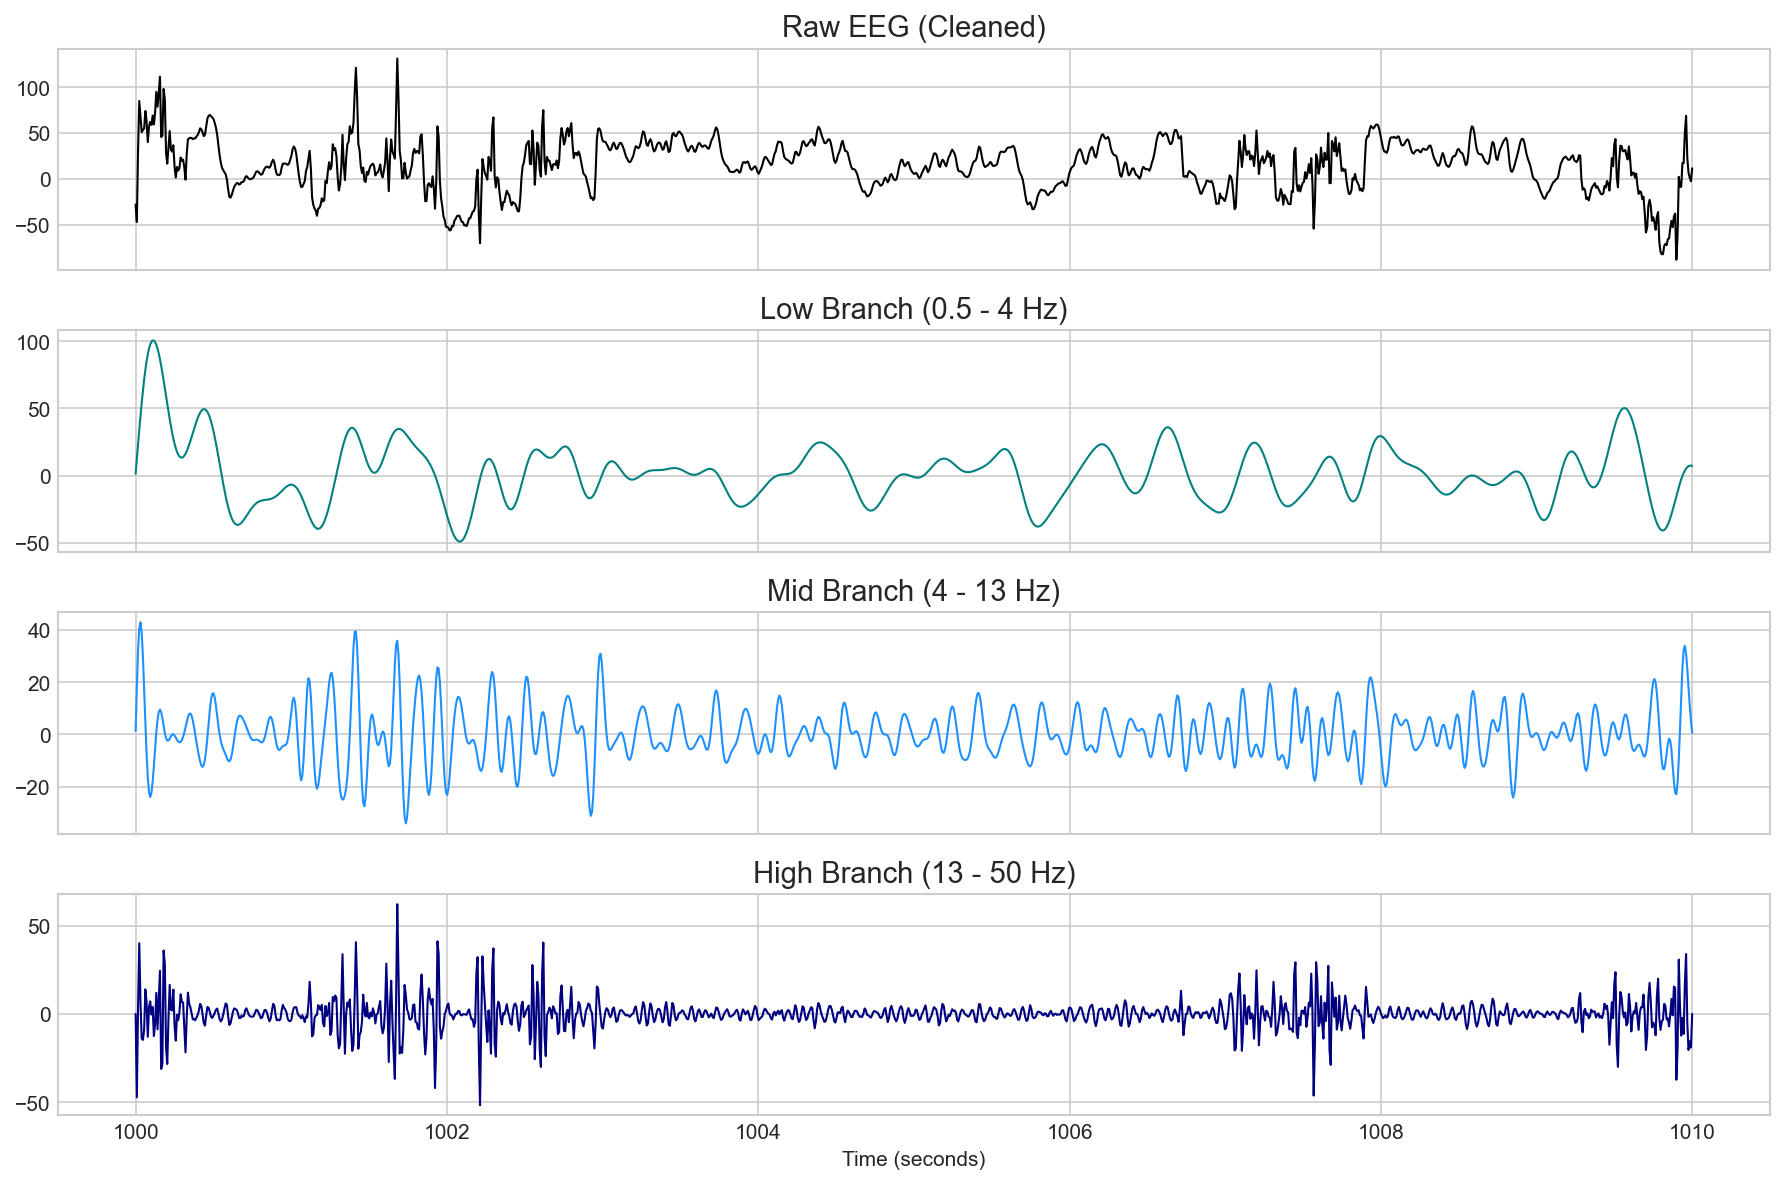

In [31]:
# Apply the filters
eeg_low = bandpass_filter(eeg_clean, 0.5, 4)
eeg_mid = bandpass_filter(eeg_clean, 4, 13)
eeg_high = bandpass_filter(eeg_clean, 13, 50)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(time_axis, eeg_clean, color='black', linewidth=1)
axs[0].set_title('Raw EEG (Cleaned)')

axs[1].plot(time_axis, eeg_low, color='teal', linewidth=1)
axs[1].set_title('Low Branch (0.5 - 4 Hz)')

axs[2].plot(time_axis, eeg_mid, color='dodgerblue', linewidth=1)
axs[2].set_title('Mid Branch (4 - 13 Hz)')

axs[3].plot(time_axis, eeg_high, color='navy', linewidth=1)
axs[3].set_title('High Branch (13 - 50 Hz)')
axs[3].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

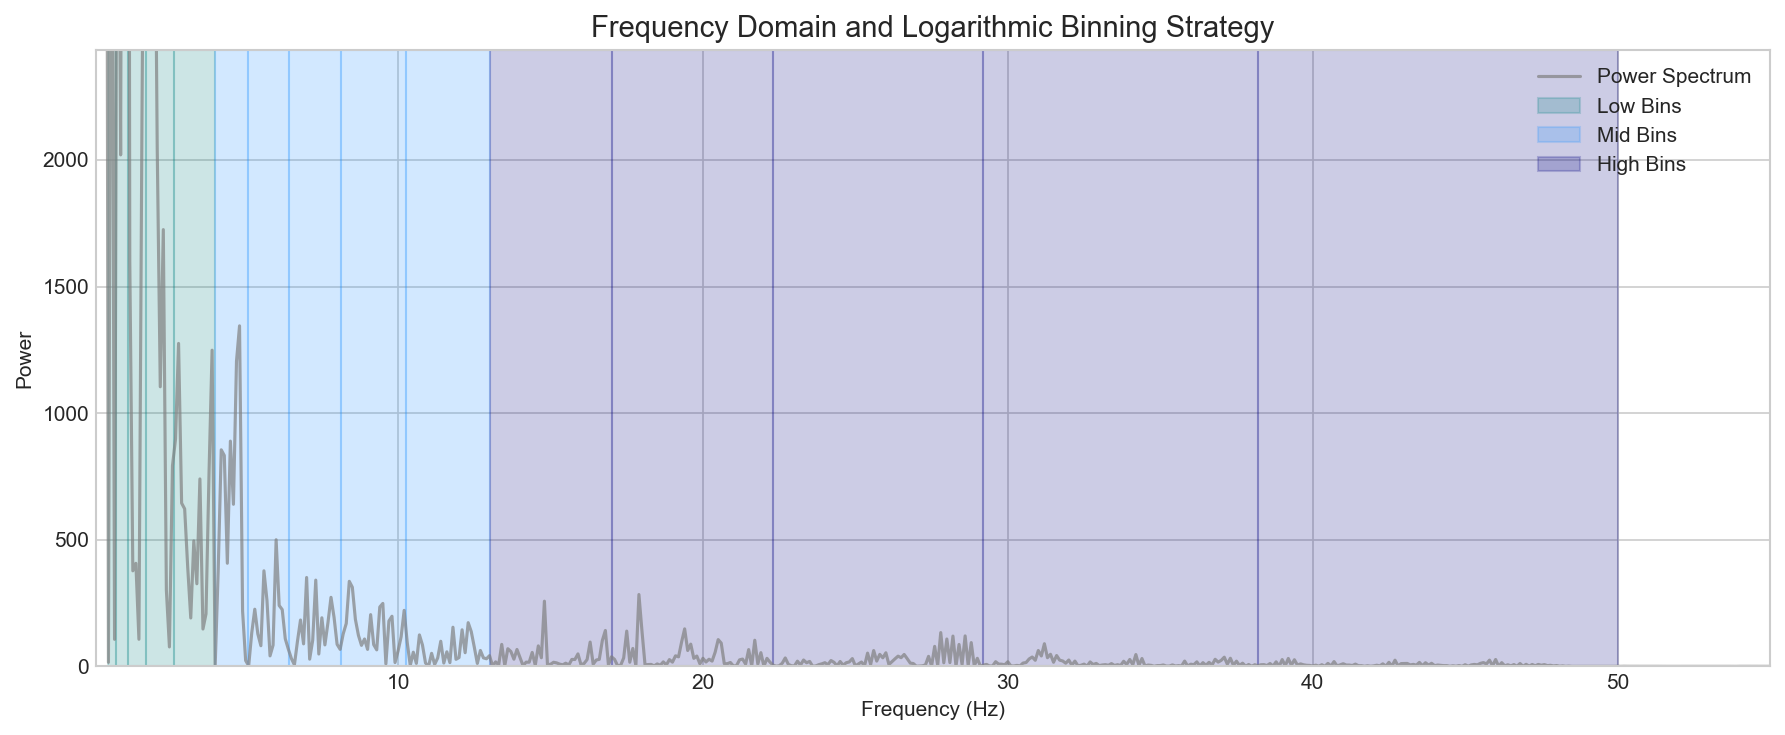

In [32]:
# Calculate FFT for the window
n = len(eeg_clean)
hann = np.hanning(n)
fft_values = np.fft.rfft(eeg_clean * hann)
freqs = np.fft.rfftfreq(n, d=1/SAMPLING_RATE)
power = (np.abs(fft_values)**2)/n  

fig, ax = plt.subplots(figsize=(12, 5))

# Plot the raw power spectrum
ax.plot(freqs, power, color='gray', alpha=0.7, label='Power Spectrum')

# Overlay the frequency bins
colors = {'low': 'teal', 'mid': 'dodgerblue', 'high': 'navy'}
labels_added = set()

for branch, edges in EDGES.items():
    for i in range(len(edges)-1):
        label = f'{branch.capitalize()} Bins' if branch not in labels_added else ""
        ax.axvspan(edges[i], edges[i+1], color=colors[branch], alpha=0.2, label=label)
        labels_added.add(branch)

ax.set_xlim(0.1, 55)
ax.set_ylim(0, np.percentile(power, 98)) # Crop outliers so we can see the bins
ax.set_title('Frequency Domain and Logarithmic Binning Strategy')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
ax.legend()

plt.tight_layout()
plt.show()

# preprocessing_1.py

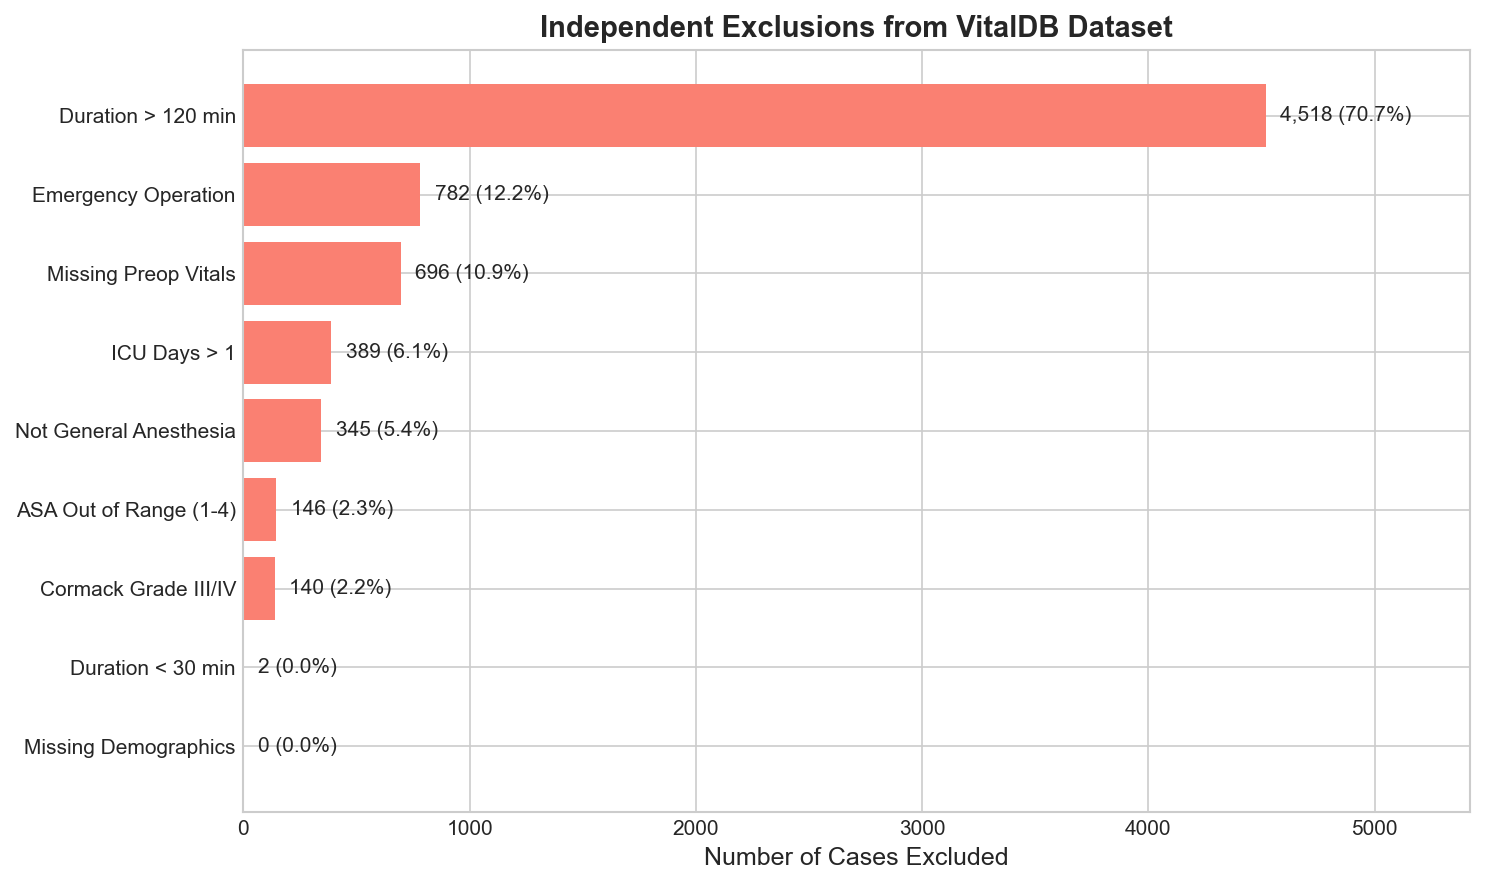

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Styling ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150

# --- 1. Load Data & Define Constants ---
# Using the same definitions from your script
df_cases = pd.read_csv("https://api.vitaldb.net/cases")
total_cases = len(df_cases)

MIN_MINUTES = 30
MAX_MINUTES = 120

# --- 2. Calculate Independent Exclusions ---
# Replicating your dictionary logic to find independent mask sums
filters = {
    "Duration < 30 min":     ~((df_cases['aneend'] - df_cases['anestart']) >= MIN_MINUTES * 60),
    "Duration > 120 min":    ~((df_cases['aneend'] - df_cases['anestart']) <= MAX_MINUTES * 60),
    "Not General Anesthesia": df_cases['ane_type'] != 'General',
    "Emergency Operation":    df_cases['emop'] != 0,
    "ASA Out of Range (1-4)": ~(df_cases['asa'].between(1, 4)),
    "ICU Days > 1":           df_cases['icu_days'] > 1,
    "Missing Demographics":   df_cases[['age', 'weight', 'bmi', 'sex']].isna().any(axis=1),
    "Cormack Grade III/IV":   ~(df_cases['cormack'].isna() | df_cases['cormack'].isin(['I', 'II'])),
    "Missing Preop Vitals":   df_cases[['preop_hb', 'preop_k', 'preop_na', 'preop_gluc', 'preop_cr', 'preop_alb']].isna().any(axis=1)
}

exclusion_counts = {reason: mask.sum() for reason, mask in filters.items()}

# --- 3. Plotting the Bar Chart ---
# Sort for a cleaner visual (highest exclusions at the top)
sorted_exclusions = dict(sorted(exclusion_counts.items(), key=lambda item: item[1]))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(list(sorted_exclusions.keys()), list(sorted_exclusions.values()), color='salmon')

# Add exact numbers and percentages to the end of the bars
for bar in bars:
    width = bar.get_width()
    percentage = (width / total_cases) * 100
    ax.text(width + (total_cases * 0.01), bar.get_y() + bar.get_height()/2, 
            f'{int(width):,} ({percentage:.1f}%)', 
            va='center', ha='left', fontsize=10)

ax.set_title('Independent Exclusions from VitalDB Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Cases Excluded', fontsize=12)
ax.set_xlim(0, max(sorted_exclusions.values()) * 1.2) # Give room for text
plt.tight_layout()
plt.show()

C:\Users\mikol\AppData\Local\Temp\ipykernel_12228\3466231676.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  remaining_df = remaining_df[condition]
C:\Users\mikol\AppData\Local\Temp\ipykernel_12228\3466231676.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  remaining_df = remaining_df[condition]
C:\Users\mikol\AppData\Local\Temp\ipykernel_12228\3466231676.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  remaining_df = remaining_df[condition]
C:\Users\mikol\AppData\Local\Temp\ipykernel_12228\3466231676.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  remaining_df = remaining_df[condition]
C:\Users\mikol\AppData\Local\Temp\ipykernel_12228\3466231676.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  remaining_df = remaining_df[condition]
C:\Users\mikol\AppData\Local\Temp\ipykernel_12228\3466231676.py:18: UserWar

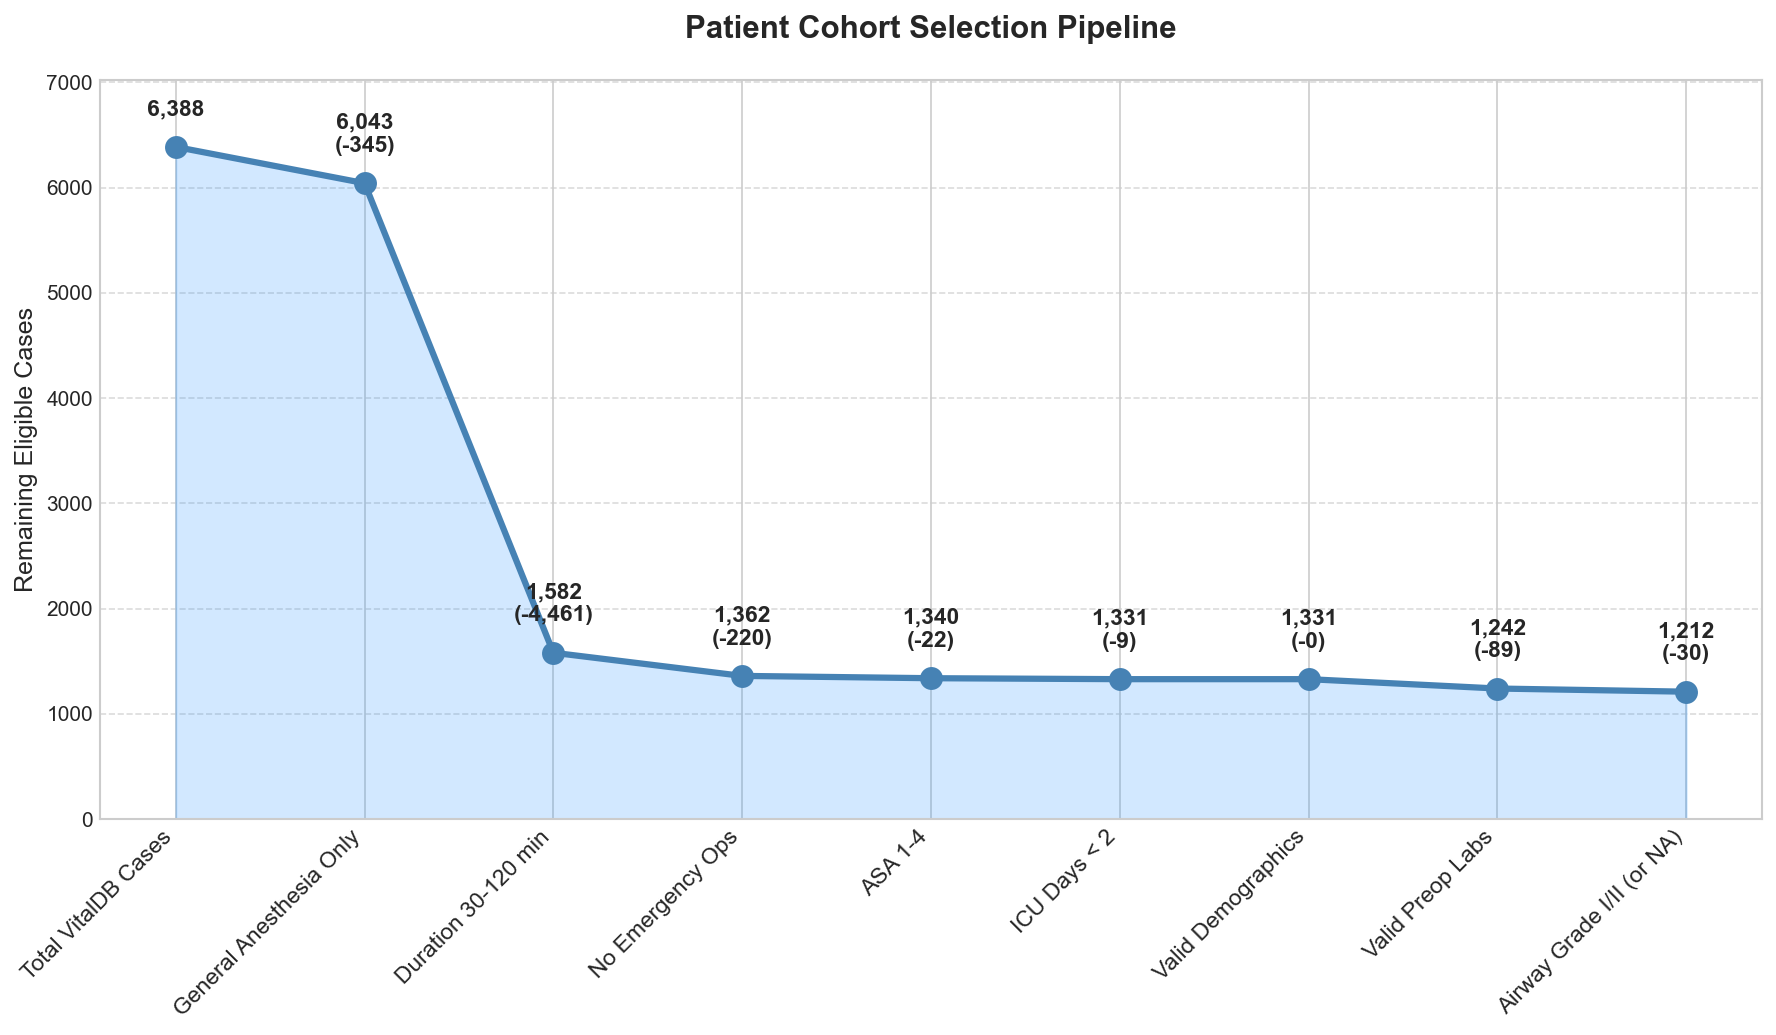

In [38]:
# --- 1. Calculate Sequential Attrition ---
remaining_df = df_cases.copy()
attrition_data = [("Total VitalDB Cases", len(remaining_df))]

# Apply filters sequentially and track the remaining count
conditions = [
    ("General Anesthesia Only", remaining_df['ane_type'] == 'General'),
    ("Duration 30-120 min", (remaining_df['aneend'] - remaining_df['anestart']).between(MIN_MINUTES*60, MAX_MINUTES*60)),
    ("No Emergency Ops", remaining_df['emop'] == 0),
    ("ASA 1-4", remaining_df['asa'].between(1, 4)),
    ("ICU Days < 2", remaining_df['icu_days'] < 2),
    ("Valid Demographics", remaining_df[['age', 'weight', 'bmi', 'sex']].notna().all(axis=1)),
    ("Valid Preop Labs", remaining_df[['preop_hb', 'preop_k', 'preop_na', 'preop_gluc', 'preop_cr', 'preop_alb']].notna().all(axis=1)),
    ("Airway Grade I/II (or NA)", remaining_df['cormack'].isna() | remaining_df['cormack'].isin(['I', 'II']))
]

for step_name, condition in conditions:
    remaining_df = remaining_df[condition]
    attrition_data.append((step_name, len(remaining_df)))

# --- 2. Plotting the Funnel / Step-Down Chart ---
steps = [x[0] for x in attrition_data]
counts = [x[1] for x in attrition_data]

fig, ax = plt.subplots(figsize=(12, 7))

# Draw the lines mapping the steps
ax.plot(steps, counts, marker='o', markersize=10, linestyle='-', linewidth=3, color='steelblue')

# Fill the area under the curve to create a funnel effect
ax.fill_between(steps, counts, color='dodgerblue', alpha=0.2)

# Annotate each point with the remaining count and the drop amount
for i, (step, count) in enumerate(attrition_data):
    if i == 0:
        text = f"{count:,}"
    else:
        drop = attrition_data[i-1][1] - count
        text = f"{count:,}\n(-{drop:,})"
        
    ax.annotate(text, (i, count), textcoords="offset points", xytext=(0, 15), 
                ha='center', fontsize=11, fontweight='bold')

ax.set_title('Patient Cohort Selection Pipeline', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Remaining Eligible Cases', fontsize=12)
ax.set_ylim(0, total_cases * 1.1)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# preprocessing_2.py